In [ ]:
# Mounting the google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Google Drive Path
gDrivePath = "gdrive/MyDrive/Colab Notebooks/COVID19_FaceMaskDetection/"

In [ ]:
# Importing the libraries
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import load_model
from google.colab.patches import cv2_imshow
import numpy as np
import argparse
import cv2
import os

In [ ]:
# Setting the Paths
imagePath = gDrivePath + "sampleTest_pictures/example_03.png"
facePath = gDrivePath + "face_detector"
modelPath = gDrivePath + "output/facemask.model"
confidenceVal = 0.5

In [ ]:
# Loading the face detector model from drive
print("Loading face detector model...")
prototxtPath = os.path.sep.join([facePath, "deploy.prototxt"])
weightsPath = os.path.sep.join([facePath, "res10_300x300_ssd_iter_140000.caffemodel"])
net = cv2.dnn.readNet(prototxtPath, weightsPath)

Loading face detector model...


In [ ]:
# Loading the face mask detector model from drive
print("Loading face mask detector model...")
model = load_model(modelPath)

Loading face mask detector model...


In [ ]:
# Loading the input image from disk,cloning it, and grabing the spatial dimensions of the image
image = cv2.imread(imagePath)
orig = image.copy()
(h, w) = image.shape[:2]

In [ ]:
# Constructing a blob from the image
## Parameters : image, scalefactor of 1 means no scaling, size, mean : mean subtraction values, swapRB: default swapping of RGB channel is done so not mentioned
## cv2.dnn.blobFromImage function returns a blob which is our input image after mean subtraction, normalizing, and channel swapping.

blob = cv2.dnn.blobFromImage(image, 1.0, (300, 300), (104.0, 177.0, 123.0))

In [ ]:
# Passing the blob through the network and obtain the face detections
print("Computing the face detections...")
net.setInput(blob)
detections = net.forward()

Computing the face detections...


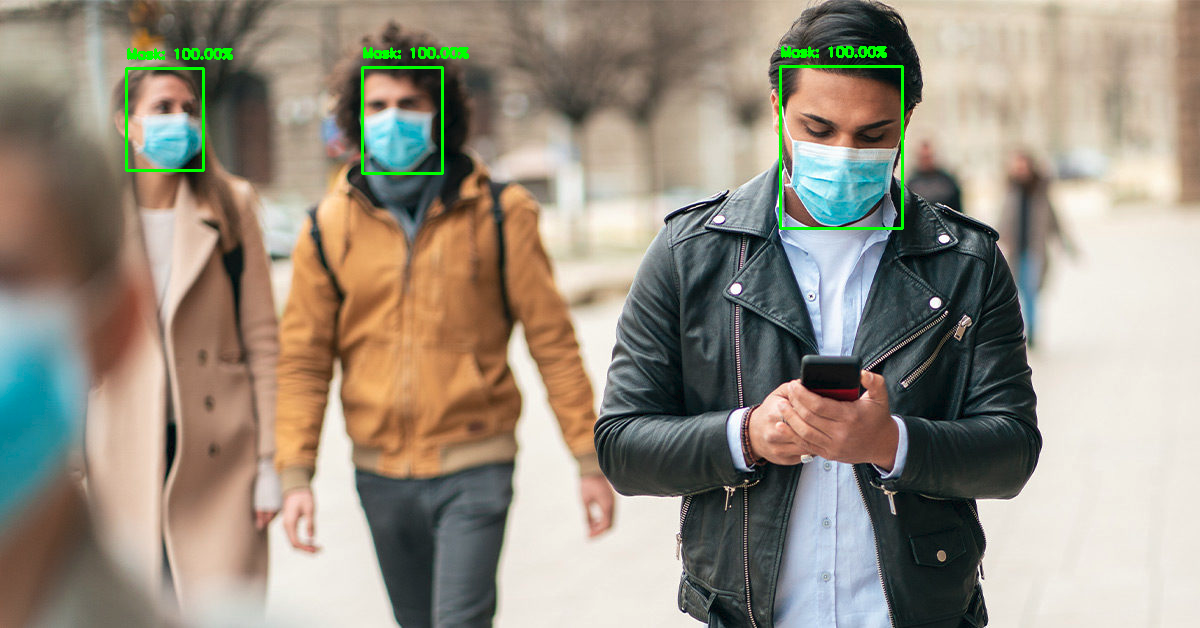

-1

In [ ]:
# Loop over the detections
for i in range(0, detections.shape[2]):
    # Extracting the confidence (that is the probability) associated with the detection
    confidence = detections[0, 0, i, 2]
    
    # Filtering out the weak detections by ensuring the confidence is greater than the minimum confidence defined above
    if confidence > confidenceVal:
        # computing the (x, y) coordinates of the bounding box for the object
        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        (startX, startY, endX, endY) = box.astype("int")
        
        #Ensuring the bounding boxes fall within the dimensions of the frame
        (startX, startY) = (max(0, startX), max(0, startY))
        (endX, endY) = (min(w - 1, endX), min(h - 1, endY))
            
        # Extracting the face ROI, convert it from BGR to RGB channel ordering, resize it to 224x224, and preprocess it
        face = image[startY:endY, startX:endX]
        face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
        face = cv2.resize(face, (224, 224))
        face = img_to_array(face)
        face = preprocess_input(face)
        face = np.expand_dims(face, axis=0)
        
        # Pass the face through the model to determine if it has mask or not
        (mask, withoutMask) = model.predict(face)[0]
  

        # Determine the class label and so the color we will use to draw the bounding box and add text
        label = "Mask" if mask > withoutMask else "No Mask"
        color = (0, 255, 0) if label == "Mask" else (0, 0, 255)
        
        # Adding the probability in the label
        label = "{}: {:.2f}%".format(label, max(mask, withoutMask) * 100)
        
        # Displaying the label and the bounding box rectangle on the output frame
        cv2.putText(image, label, (startX, startY - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 2)
        cv2.rectangle(image, (startX, startY), (endX, endY), color, 2)
        
# Showing the output image
cv2_imshow(image)
cv2.waitKey(0)